In [1]:
import os 
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from typing import TypedDict, Literal
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

load_dotenv()

True

In [2]:
MODEL_NAME ='qwen/qwen3.8-27b'

In [3]:
model = ChatGroq(model = MODEL_NAME, max_tokens=1300)

In [4]:
from typing import Annotated

class structure_class(BaseModel):
    evaluate : Literal['approved', 'needs_research', 'needs_improved_writing', 'needs_editing']
    feedback:str = Field(description='Give brief description what , why and where it needs improvements ', default='No feedback yet')

structured_model = model.with_structured_output(structure_class)


class post_state(TypedDict):
    topic : str
    post : str
    messages : Annotated[list, add_messages]   # NEW: holds the research tool-calling loop
    research_message : str
    write_message : str
    edit_message : str
    evaluate : Literal['approved', 'needs_research', 'needs_improved_writing', 'needs_editing']
    iteration : int
    max_iteration :int 
    feedback:str
    tool_call_count:int

In [5]:
# from duckduckgo_search import DDGS
from ddgs import DDGS
@tool
def duckduckgo_search(query: str) -> str:
    """Search the web using DuckDuckGo to get real-time information and current events."""
    try:
        with DDGS() as ddgs:
            results = [r for r in ddgs.text(query, max_results=5)]
            if not results:
                return "No results found."
            
            # Format results into a clean string for the LLM
            formatted_results = []
            for r in results:
                snippet  = r['body'][:300]
                formatted_results.append(f"Title: {r['title']}\nSnippet: {snippet}\nURL: {r['href']}\n")
            return "\n---\n".join(formatted_results)
            
    except Exception as e:
        return f"Error executing search: {str(e)}"


tools = [duckduckgo_search]
model_with_tools = model.bind_tools(tools)

In [6]:
from langgraph.prebuilt import ToolNode, tools_condition
tool_node = ToolNode(tools)

In [7]:
MAX_TOOL_CALLS = 5

def research_func(state: post_state):
    topic = state['topic']
    feedback = state.get('feedback', '')
    messages = state.get('messages', [])
    tool_call_count = state.get('tool_call_count', 0)

    resuming_after_tool_call = bool(messages) and getattr(messages[-1], 'type', None) == 'tool'

    if resuming_after_tool_call:
        tool_call_count += 1        # a tool round-trip just completed
        messages_to_send = messages
    else:
        # fresh pass (first run, or supervisor sent us back with 'needs_research')
        SYSTEM_PROMPT = """...(unchanged)..."""
        messages_to_send = [SystemMessage(content=(SYSTEM_PROMPT + feedback)), HumanMessage(content=topic)]
        tool_call_count = 0          # reset budget for this fresh research pass

    if tool_call_count >= MAX_TOOL_CALLS:
        # budget used up — invoke the PLAIN model (no tools bound) so it
        # physically cannot request another tool call, and must answer now
        forced = messages_to_send + [HumanMessage(
            content="You've used the search tool the maximum number of times. "
                    "Do not call any more tools — write your final research summary now."
        )]
        ai_message = model.invoke(forced)
        messages_to_send = forced
    else:
        try:
            ai_message = model_with_tools.invoke(messages_to_send)
        except Exception as e:
            if "tool_use_failed" in str(e) or "not in request.tools" in str(e):
                retry = messages_to_send + [HumanMessage(content="Reminder: you only have the duckduckgo_search tool. Do not call any other tool.")]
                ai_message = model_with_tools.invoke(retry)
                messages_to_send = retry
            else:
                raise

    new_messages = [ai_message] if resuming_after_tool_call else messages_to_send + [ai_message]
    result = {'messages': new_messages, 'tool_call_count': tool_call_count}

    if not getattr(ai_message, 'tool_calls', None):
        result['research_message'] = ai_message.content

    return result




def write_func(state:post_state):
    """You are  a professional writer. 
    you have been provided with a researched content , you need to write that research content in a  way such that user can understand,
    what is this content is about , make sure it's meaning did not change.
     and at the end there should be a brief conclusion paragraph , taht will state the whole idea of the blog. """

    research_message = state['research_message']
    feedback = state.get('feedback', '')
    SYSTEM_PROMPT = """You are a professional blog writer. Turn the research below into an
    engaging blog post for a general audience, preserving its meaning, and end with a short
    conclusion paragraph. if a supervisor thinks it needs improvements , then it will give you feedback, if then you need to consider it .
     Research content:\n\n"""
    response = model.invoke([SystemMessage(content=(SYSTEM_PROMPT+feedback)), HumanMessage(content=research_message)]).content
    return {'write_message': response}


def edit_func(state : post_state):
    """You are a professional BLOG post editor. 
    the topic and all the content will be provided to you.
    you need to make final changes/improvements if needed , such that after that it will be final for posting.
    give me in that format so that i can just copy paste it.  """

    SYSTEM_PROMPT = """You are a professional BLOG post editor. 
    if a supervisor thinks it further need edits , it will give you feedback , you need to consider it .
    you need to make final changes/improvements/edit if needed , such that after that it will be final for posting.
    give me in that format so that i can just copy paste it. """  

    write_message = state['write_message']
    feedback = state.get('feedback', '')
    response = model.invoke([SystemMessage(content=(SYSTEM_PROMPT+feedback)), HumanMessage(content=write_message)]).content
    
    return {'edit_message':response, 'post':response}

In [8]:
def supervisor_func(state:post_state):
    """You are a Professional Supervisor.
    Here there will be provided you a BLOG post title and content ,
    you need to evaluate it such that , if any changes to be needed you can point out."""

    edit_message = state['edit_message']
    if len(edit_message.split())>=7500:
        edit_message = model.invoke([SystemMessage(content=f'short the lenght of this message, such that it should not be greater than 7500 tokens'), HumanMessage(content=edit_message)]).content

    SYSTEM_PROMPT = """ You are a professional supervisor. 
                        you need to evaluate this post content based on "research, writing and editing", 
                         and if any improvement/changes needed , you can mention it.
                         Just give your response from one of the following ['approved', 'needs_research', 'needs_improved_writing', 'needs_editing'].
                         no need to give anything else.
                         and make sure it's length/tokens don't exceed more than 7500 words/tokens.
                         give response in a dictionary format such as {'evaluate': .., 'feedback': ..}
                         BLOG Post content is : """

    response = structured_model.invoke([SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=edit_message)])

    iteration = state['iteration'] + 1

    return {'evaluate': response.evaluate.strip().lower() , 'iteration':iteration, 'feedback':response.feedback}


def router(state:post_state) -> Literal['approved', 'needs_research', 'needs_improved_writing', 'needs_editing']:
    if state['evaluate'] == 'approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    elif state['evaluate'] == 'needs_research':
        return 'needs_research'
    elif state['evaluate'] == 'needs_improved_writing':
        return 'needs_improved_writing'
    elif state['evaluate'] == 'needs_editing':
        return 'needs_editing'

In [9]:
graph = StateGraph(post_state)

graph.add_node('research_node', research_func)
graph.add_node('tool_node', tool_node)
graph.add_node('write_node', write_func)
graph.add_node('edit_node', edit_func)
graph.add_node('supervisor_node', supervisor_func)

graph.add_edge(START, 'research_node')
graph.add_conditional_edges('research_node', tools_condition, {'tools': 'tool_node', END: 'write_node'})
graph.add_edge('tool_node', 'research_node')   # feed tool results back to the model
graph.add_edge('write_node', 'edit_node')
graph.add_edge('edit_node', 'supervisor_node')
graph.add_conditional_edges('supervisor_node', router, {'approved':END, 'needs_research':'research_node', 'needs_improved_writing':'write_node', 'needs_editing':'edit_node'})


workflow = graph.compile()

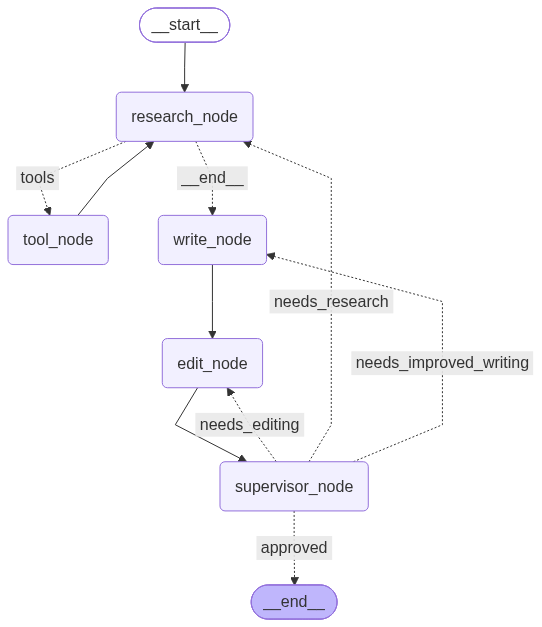

In [10]:
workflow

In [13]:
initial_state = {'topic':'Pakistan condition in past and future, still same or better ? ', 
                 'iteration': 1, 
                 'max_iteration':5}

# final_response = workflow.invoke(initial_state)

final_response1 = ''        # research message
final_response2 = ''        # write message
final_response3 = ''        # edit message

for mode, data in workflow.stream(initial_state, stream_mode=["updates", "custom"],    config = {'recursion_limit':50}):
    if mode == "updates":
        for node_name, state in data.items():
            print(f"Node {node_name} updated: {state}")
            if node_name=='research_node':
                final_response1 = state
            elif node_name=='write_node':
                final_response2 = state
            elif node_name=='edit_node':
                final_response3 = state
    elif mode == "custom":
        print(f"Status: {mode}")


Node research_node updated: {'messages': [SystemMessage(content='...(unchanged)...', additional_kwargs={}, response_metadata={}, id='15b3d035-fc3c-47e8-8a53-e9d2b300f426'), HumanMessage(content='Pakistan condition in past and future, still same or better ? ', additional_kwargs={}, response_metadata={}, id='00a558ac-94f4-48e3-a5a4-807597b7befd'), AIMessage(content='To answer whether Pakistan\'s condition is "still the same or better," we need to look at several key pillars of national health: **Economy, Security, Diplomacy, and Social Development**.\n\nThe short answer is: **It is mixed.** Some areas have improved significantly (especially security and regional diplomacy), while others remain stagnant or have worsened (economic stability and social indicators).\n\nHere’s a breakdown:\n\n### 1. Security Situation\n- **Past (2010s–early 2020s):** Pakistan faced severe internal security threats from the TTP (Tehrik-i-Taliban Pakistan) and other militant groups. The military launched large-

In [14]:
print(final_response3['edit_message'])

Here is the polished, final version of the blog post. I have refined the tone to be more engaging and authoritative, tightened the sentence structure for better flow, and ensured the formatting is clean for immediate copy-pasting. I also slightly sharpened the "Verdict" section to make the conclusion punchier.

***

# Beyond the Headlines: Is Pakistan Better Off, or Just Different?

When you ask someone from Pakistan if things are "better" or "the same" as they were a decade ago, you rarely get a simple yes or no. The answer is a complex mosaic of progress and persistent struggle. To understand where the nation stands today, we must look beyond the daily noise and examine the four key pillars of national health: the economy, security, diplomacy, and social development.

The short answer is: **It is mixed.**

While Pakistan has made undeniable strides in keeping its citizens safer and boosting its regional influence, it is currently grappling with economic headwinds that make daily life